# Open vs. closed chromatin: TFBS drivers of NGN2 element activity

In [ ]:
import os
import sys
import ast
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import r2_score
from scipy.stats import kendalltau, spearmanr, fisher_exact

sys.path.append("../00_helpful_functions")
import helpful_functions as hf

# only these four columns in the element annotation table are stored as
# string-encoded lists/tuples and need literal_eval'ing
col_variant_class = "variant_class"
col_variant_pos = "variant_pos"
col_SPDI = "SPDI"
col_allele = "allele"
list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

writing = False  # set True to (re)write BED/TSV/figure output files
base_figure_dir = "data/"


def safe_eval(x):
    """Literal_eval a string-encoded list column, leaving non-string/NaN values untouched."""
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x


def normalize_name(name):
    """';'-separated element name -> alphabetically sorted (reverse) ';'-joined name."""
    parts = sorted(part.strip() for part in name.split(";"))
    parts = sorted(parts, reverse=True)
    return ";".join(parts)


def preprocess_metadata_df(metadata_df, list_columns):
    for col in list_columns:
        metadata_df[col] = metadata_df[col].apply(safe_eval)
    metadata_df["normalized_name"] = metadata_df["name"].apply(normalize_name)
    return metadata_df.copy()

## Load element annotation and NGN2 activity tables, merge

In [2]:
# read annotation table
annotation_table_input_path = "./data/2606_ref_element_annotation_n_24510.tsv.gz"
combined_annotation_activity_element_raw = pd.read_csv(annotation_table_input_path, sep="\t", low_memory=False)
combined_annotation_activity_element_raw = preprocess_metadata_df(combined_annotation_activity_element_raw, list_columns)


## Drop elements with no phastCons conservation coverage
phastCons_sum/mean0/mean already come from the element annotation table itself 

In [3]:
# a small number of sequences are only partly covered by phastCons, which would introduce
# noise/bias rather than signal -> drop rather than impute (only 1 of them is significant)
print(f"Initial number of sequences: {combined_annotation_activity_element_raw.shape[0]}")
combined_annotation_activity_element = combined_annotation_activity_element_raw.loc[
    ~combined_annotation_activity_element_raw["phastCons_sum"].isna()
].copy()
print(f"Number of sequences after removing those with missing phastCons: {combined_annotation_activity_element.shape[0]}")

# REMAP2022 TFBS counts: missing means "zero binding sites observed"
combined_annotation_activity_element["REMAP2022_number_of_TFBS"] = combined_annotation_activity_element["REMAP2022_number_of_TFBS"].fillna(0)
combined_annotation_activity_element["REMAP2022_n_unique_TFBS"] = combined_annotation_activity_element["REMAP2022_n_unique_TFBS"].fillna(0)

Initial number of sequences: 24510
Number of sequences after removing those with missing phastCons: 24468


## Active ("dCRE") elements: BED files for the external TFBS enrichment workflow
Used by `smk_element_driver_enrichment` (see
`generate_input_bed_files.ipynb` there) to compute REMAP2022 per-TF sequence counts
for active-brain vs. active-non-brain elements, merged back in below.

In [ ]:
dcre_table = combined_annotation_activity_element_raw.loc[
    combined_annotation_activity_element_raw["significant_region_NGN2"]
].copy()
active_brain_cres = dcre_table.loc[dcre_table["is_brain_SCREEN_cCRE"]].copy()
active_non_brain_cres = dcre_table.loc[~dcre_table["is_brain_SCREEN_cCRE"]].copy()
print(f"Number of active brain cCREs: {active_brain_cres.shape[0]}")
print(f"Number of active non-brain cCREs: {active_non_brain_cres.shape[0]}")



if writing:
    output_dir = "data/active_brain_vs_active_non_brain"
    # make sure the output dir exists
    os.makedirs(output_dir, exist_ok=True)

    active_brain_cres = active_brain_cres.sort_values(by=["chr", "start", "end"])
    active_non_brain_cres = active_non_brain_cres.sort_values(by=["chr", "start", "end"])
    active_brain_cres[["chr", "start", "end", "name"]].to_csv(
        os.path.join(output_dir, "2602_active_brain_elements.bed.gz"), sep="\t", header=False, index=False, compression="gzip"
    )
    active_non_brain_cres[["chr", "start", "end", "name"]].to_csv(
        os.path.join(output_dir, "2602_active_non_brain_elements.bed.gz"), sep="\t", header=False, index=False, compression="gzip"
    )

Number of active brain cCREs: 580
Number of active non-brain cCREs: 1108


## Merge REMAP2022 per-TF sequence-level counts
`zcat .../only_regions_tested_80k_MPRA_CREs_remap2022_filtered_summit_overlap_no_border_overlap_min_10bp.bed.gz | grep "REST" | gzip > .../only_regions_tested_80k_MPRA_CREs_remap2022_REST.bed.gz`
is one example of how a single-TF subset was pulled out of the enrichment workflow's
resources for a targeted look (e.g. REST enrichment outside brain cCREs).

In [5]:
combined_annotation_activity_element.columns.to_list()

['name',
 'sequence',
 'category',
 'class',
 'source',
 'ref',
 'chr',
 'start',
 'end',
 'strand',
 'variant_class',
 'variant_pos',
 'SPDI',
 'allele',
 'info',
 'normalized_name',
 'logFC',
 'adj.P.Val',
 'normalized_activity_NGN2',
 'significant_region_NGN2',
 'effect_direction_NGN2',
 'region_info',
 'brain_e2g_cell_type',
 'brain_e2g_gene_name',
 'brain_e2g_score',
 'brain_e2g_distance_to_TSS',
 'cardiac_e2g_cell_type',
 'cardiac_e2g_gene_name',
 'cardiac_e2g_score',
 'cardiac_e2g_distance_to_TSS',
 'gene_id',
 'closest_tss_gene_name',
 'tss_distance',
 'gene_name',
 'gene_set',
 'SCREEN_ID',
 'is_ngn2_atac_overlap',
 'is_brain_SCREEN_cCRE',
 'is_heart_SCREEN_cCRE',
 'is_H1_SCREEN_cCRE',
 'dELS_is_brain_SCREEN_cCRE_group',
 'CA-only_is_brain_SCREEN_cCRE_group',
 'PLS_is_brain_SCREEN_cCRE_group',
 'pELS_is_brain_SCREEN_cCRE_group',
 'CA-H3K4me3_is_brain_SCREEN_cCRE_group',
 'CA-TF_is_brain_SCREEN_cCRE_group',
 'CA-only_is_heart_SCREEN_cCRE_group',
 'PLS_is_heart_SCREEN_cCRE_group

In [6]:
interesting_annotation_cols = [
    "is_brain_e2g_overlap", "tss_distance", "is_ngn2_atac_overlap", "is_brain_SCREEN_cCRE",
    "is_heart_SCREEN_cCRE", "is_H1_SCREEN_cCRE",
    "dELS_is_brain_SCREEN_cCRE_group", "CA-only_is_brain_SCREEN_cCRE_group", "PLS_is_brain_SCREEN_cCRE_group",
    "pELS_is_brain_SCREEN_cCRE_group", "CA-H3K4me3_is_brain_SCREEN_cCRE_group", "CA-TF_is_brain_SCREEN_cCRE_group",
    "CA-only_is_heart_SCREEN_cCRE_group", "PLS_is_heart_SCREEN_cCRE_group", "dELS_is_heart_SCREEN_cCRE_group",
    "pELS_is_heart_SCREEN_cCRE_group", "CA-H3K4me3_is_heart_SCREEN_cCRE_group", "CA-TF_is_heart_SCREEN_cCRE_group",
    "PLS_is_H1_SCREEN_cCRE_group", "CA-TF_is_H1_SCREEN_cCRE_group", "CA-H3K4me3_is_H1_SCREEN_cCRE_group",
    "CA-only_is_H1_SCREEN_cCRE_group", "pELS_is_H1_SCREEN_cCRE_group", "dELS_is_H1_SCREEN_cCRE_group",
    "PLS_is_WTC11_SCREEN_cCRE_group", "pELS_is_WTC11_SCREEN_cCRE_group", "dELS_is_WTC11_SCREEN_cCRE_group",
    "has_overlapping_brain_eQTL", "REMAP2022_number_of_TFBS", "REMAP2022_n_unique_TFBS",
    "phastCons_sum", "phastCons_mean0", "phastCons_mean", "singleton_overlap_count",
]

combined_annotation_activity_element["is_brain_e2g_overlap"] = combined_annotation_activity_element["brain_e2g_score"].notna()

combined_annotation_activity_elements_df = combined_annotation_activity_element[
    ["name", "chr"] + ["normalized_activity_NGN2", "significant_region_NGN2"] + interesting_annotation_cols
]

if writing:
    output_path = "data/region_annotation_and_activity_ngn2_for_enrichment_analysis.tsv.gz"
    combined_annotation_activity_elements_df.to_csv(output_path, sep="\t", index=False, compression="gzip")


tfbs_table_path = "data/remap_overlap/NGN2_Active_vs_Inactive_elements_tf_counts.tsv.gz"
tfbs_table_df = pd.read_csv(tfbs_table_path, sep="\t")
tfbs_table_df.rename(columns={"sequence_name": "name"}, inplace=True)
tfbs_table_df_unique = tfbs_table_df.drop_duplicates(subset=["name"])

tfbs_columns = [col for col in tfbs_table_df.columns if col not in ["name", "activity_category"]]

combined_annotation_activity_tfbs_count_elements_df = combined_annotation_activity_elements_df.merge(
    tfbs_table_df_unique[["name"] + tfbs_columns], on="name", how="left",
)
for col in tfbs_columns:
    combined_annotation_activity_tfbs_count_elements_df[col] = combined_annotation_activity_tfbs_count_elements_df[col].fillna(0)

combined_annotation_activity_tfbs_count_elements_df

,name,chr,normalized_activity_NGN2,significant_region_NGN2,is_brain_e2g_overlap,tss_distance,is_ngn2_atac_overlap,is_brain_SCREEN_cCRE,is_heart_SCREEN_cCRE,is_H1_SCREEN_cCRE,...,ZSCAN26,ZSCAN29,ZSCAN30,ZSCAN31,ZSCAN4,ZSCAN5A,ZSCAN5C,ZXDB,ZXDC,ZZZ3
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,chr1,-2.213458,False,False,2276.0,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,chr1,0.853657,False,False,1680.0,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,chr1,-0.340121,False,False,4001.0,False,True,False,True,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,chr1,0.075463,False,False,8248.0,False,False,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,chr1,-2.691331,True,False,8873.0,False,False,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24463,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,chrX,-0.593700,False,False,3225.0,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24464,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,chrX,0.923027,False,True,1874.0,False,True,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24465,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,chrX,1.590710,False,False,2302.0,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
24466,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,chrX,-2.410187,False,False,2231.0,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Build the elastic-net feature matrix
Binary cCRE/eQTL/E2G overlap flags, continuous conservation/TFBS-density features,
and per-TF REMAP2022 sequence counts (~1000+ columns, filtered to TFs observed in at
least 10 sequences).

In [ ]:
RANDOM_SEED = 42
TEST_CHROMOSOME_PROPORTION = 0.20
CHROMOSOME_SPLIT_FILE = "data/chromosome_split.json"
target_col = "normalized_activity_NGN2"

# all_binary_cols: every binary annotation flag fed to the main elastic net model and
# the downsampling-robustness checks below. binary_cols is a narrower brain/heart-only
# subset (no WTC11/H1 flags) that the ordinal-target model near the end of this script
# uses instead that difference is preserved from the original analysis as-is rather
# than unified, since it's unclear which was the deliberate choice.
all_binary_cols = [
    "is_ngn2_atac_overlap",
    "PLS_is_WTC11_SCREEN_cCRE_group", "pELS_is_WTC11_SCREEN_cCRE_group", "dELS_is_WTC11_SCREEN_cCRE_group",
    "PLS_is_H1_SCREEN_cCRE_group", "CA-TF_is_H1_SCREEN_cCRE_group", "CA-H3K4me3_is_H1_SCREEN_cCRE_group",
    "CA-only_is_H1_SCREEN_cCRE_group", "pELS_is_H1_SCREEN_cCRE_group", "dELS_is_H1_SCREEN_cCRE_group",
    "is_H1_SCREEN_cCRE", "has_overlapping_brain_eQTL", "is_brain_e2g_overlap", "is_brain_SCREEN_cCRE",
    "is_heart_SCREEN_cCRE", "dELS_is_brain_SCREEN_cCRE_group", "CA-only_is_brain_SCREEN_cCRE_group",
    "PLS_is_brain_SCREEN_cCRE_group", "pELS_is_brain_SCREEN_cCRE_group", "CA-H3K4me3_is_brain_SCREEN_cCRE_group",
    "CA-TF_is_brain_SCREEN_cCRE_group", "CA-only_is_heart_SCREEN_cCRE_group", "PLS_is_heart_SCREEN_cCRE_group",
    "dELS_is_heart_SCREEN_cCRE_group", "pELS_is_heart_SCREEN_cCRE_group", "CA-H3K4me3_is_heart_SCREEN_cCRE_group",
    "CA-TF_is_heart_SCREEN_cCRE_group",
]

# narrower subset (brain/heart only, no WTC11/H1) used only by the ordinal-target
# model near the end of this script, see note above
binary_cols = [
    "is_ngn2_atac_overlap", "is_H1_SCREEN_cCRE", "has_overlapping_brain_eQTL", "is_brain_e2g_overlap",
    "is_brain_SCREEN_cCRE", "is_heart_SCREEN_cCRE", "dELS_is_brain_SCREEN_cCRE_group",
    "CA-only_is_brain_SCREEN_cCRE_group", "PLS_is_brain_SCREEN_cCRE_group", "pELS_is_brain_SCREEN_cCRE_group",
    "CA-H3K4me3_is_brain_SCREEN_cCRE_group", "CA-TF_is_brain_SCREEN_cCRE_group",
    "CA-only_is_heart_SCREEN_cCRE_group", "PLS_is_heart_SCREEN_cCRE_group", "dELS_is_heart_SCREEN_cCRE_group",
    "pELS_is_heart_SCREEN_cCRE_group", "CA-H3K4me3_is_heart_SCREEN_cCRE_group", "CA-TF_is_heart_SCREEN_cCRE_group",
]

continuous_cols = [
    "REMAP2022_number_of_TFBS", "REMAP2022_n_unique_TFBS", "phastCons_sum",
    "phastCons_mean0", "phastCons_mean", "singleton_overlap_count", "tss_distance",
]


def get_tfbs_columns(df, binary_cols, continuous_cols, target_col, exclude_cols):
    exclude = set(binary_cols + continuous_cols + [target_col, "chr", "sequence_name", "name"] + exclude_cols)
    return [c for c in df.columns if c not in exclude]


def filter_tfbs_columns(df, tfbs_cols, min_nonzero=10):
    """Drop zero-variance TFBS columns and TFs observed in fewer than min_nonzero sequences."""
    tfbs_cols = [c for c in tfbs_cols if df[c].nunique() > 1]
    tfbs_cols = [c for c in tfbs_cols if (df[c] > 0).sum() >= min_nonzero]
    return tfbs_cols


def scale_columns(df, continuous_cols, tfbs_cols):
    scaler = StandardScaler()
    df_scaled = df.copy()
    cols_to_scale = continuous_cols + tfbs_cols
    df_scaled[cols_to_scale] = scaler.fit_transform(df_scaled[cols_to_scale])
    return df_scaled, scaler


def chromosome_split(df):
    """Fixed 80/20 train/test split by chromosome, cached to CHROMOSOME_SPLIT_FILE for reuse."""
    chromosomes = sorted(df["chr"].unique())
    if os.path.exists(CHROMOSOME_SPLIT_FILE):
        with open(CHROMOSOME_SPLIT_FILE, "r") as f:
            split = json.load(f)
        return split["train"], split["test"]

    n_test = int(len(chromosomes) * TEST_CHROMOSOME_PROPORTION)
    np.random.seed(RANDOM_SEED)
    test_chroms = list(np.random.choice(chromosomes, n_test, replace=False))
    train_chroms = [c for c in chromosomes if c not in test_chroms]
    with open(CHROMOSOME_SPLIT_FILE, "w") as f:
        json.dump({"train": train_chroms, "test": test_chroms}, f)
    return train_chroms, test_chroms


def train_elastic_net(X_train, y_train):
    model = ElasticNetCV(l1_ratio=[0.2, 0.5, 0.8], cv=5, n_jobs=-1, random_state=RANDOM_SEED, max_iter=5000, tol=1e-4)
    model.fit(X_train, y_train)
    return model


def compute_regression_metrics(y_true, y_pred):
    """R^2, Kendall Tau (+ Tau^2), and Spearman correlation between predicted and true activity."""
    tau, _ = kendalltau(y_true, y_pred)
    rho, _ = spearmanr(y_true, y_pred)
    return {
        "r2": r2_score(y_true, y_pred),
        "kendall_tau": tau,
        "kendall_tau2": tau * tau if tau is not None else np.nan,
        "spearman_rho": rho,
    }


# Identify TFBS columns actually present in the merged table (unfiltered — this is the
# list used throughout the interpretation sections further down, distinct from the
# min-nonzero-filtered `tfbs_cols_filtered` used only for model fitting)
tfbs_cols = get_tfbs_columns(
    combined_annotation_activity_tfbs_count_elements_df, all_binary_cols, continuous_cols, target_col,
    exclude_cols=["significant_region_NGN2", "chr"],
)
feature_cols = all_binary_cols + continuous_cols + tfbs_cols

# "significant_region_NGN2" is not a model feature but is needed by the repeated-
# downsampling robustness checks further down, which reuse this same df_scaled to tell
# significant from non-significant elements
df = combined_annotation_activity_tfbs_count_elements_df[
    feature_cols + [target_col] + ["chr", "significant_region_NGN2"]
].copy()

df[all_binary_cols] = df[all_binary_cols].astype(int)
df[tfbs_cols] = df[tfbs_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)

tfbs_cols_filtered = filter_tfbs_columns(df, tfbs_cols, min_nonzero=10)
print(f"TFBS columns kept: {len(tfbs_cols_filtered)}")

df_scaled, scaler = scale_columns(df, continuous_cols, tfbs_cols_filtered)

# takes: 9 seconds

TFBS columns kept: 990


## Chromosome-based train/test split and elastic net fit
This refit is kept for reference (it reproduces how the saved model below was
originally produced) but its result is not what generates the published figure —
see "Load the saved elastic-net model" further down, which overwrites
`model_all_regions`/`feature_cols` with the pre-fit model actually used for Fig. 2d.
Retraining as a reusable, documented CLI step now lives in
`09_mpra_manuscript/analysis/02_cre_sequence_features/train_elastic_net.py`.

In [ ]:
train_chroms, test_chroms = chromosome_split(df)
train_idx = df_scaled["chr"].isin(train_chroms)
test_idx = df_scaled["chr"].isin(test_chroms)

X_train = df_scaled.loc[train_idx, feature_cols]
y_train = df_scaled.loc[train_idx, target_col]
X_test = df_scaled.loc[test_idx, feature_cols]
y_test = df_scaled.loc[test_idx, target_col]

model_all_regions = train_elastic_net(X_train, y_train)
print(f"Train R2: {r2_score(y_train, model_all_regions.predict(X_train)):.4f}")
print(f"Test R2:  {r2_score(y_test,  model_all_regions.predict(X_test)):.4f}")


current_metrics_train = compute_regression_metrics(y_train, model_all_regions.predict(X_train))
current_metrics_test = compute_regression_metrics(y_test, model_all_regions.predict(X_test))
print("TRAIN:", current_metrics_train)
print("TEST :", current_metrics_test)

output_dir = "data/remap_overlap"
if writing:
    os.makedirs(output_dir, exist_ok=True)
    model_output_path = f"{output_dir}/2606_ngn2_activity_elastic_net_model_all_regions_removed_na_phastcons_R2_test_0.0308.pkl"
    coefficients_output_path = f"{output_dir}/2606_ngn2_activity_elastic_net_model_coefficients_all_regions_removed_na_phastcons_R2_test_0.0308.tsv"
    joblib.dump(model_all_regions, model_output_path)
    coef_df = pd.DataFrame({"feature": feature_cols, "coefficient": model_all_regions.coef_})
    coef_df.to_csv(coefficients_output_path, sep="\t", index=False)

# takes: > 1 minute

## Load the saved elastic-net model
The manuscript's coefficient figure (Fig. 2d) was produced from this saved,
pre-fit model — not the refit immediately above. Loading here overwrites both
`model_all_regions` and `feature_cols` (the coefficient table's feature order,
which is the order used for every interpretation step below).

In [11]:
model_input_path = f"{output_dir}/2606_ngn2_activity_elastic_net_model_all_regions_removed_na_phastcons_R2_test_0.0308.pkl"
model_all_regions = joblib.load(model_input_path)

coefficients_input_path = f"{output_dir}/2606_ngn2_activity_elastic_net_model_coefficients_all_regions_removed_na_phastcons_R2_test_0.0308.tsv"
feature_cols_curr_model_df = pd.read_csv(coefficients_input_path, sep="\t")
feature_cols_curr_model = feature_cols_curr_model_df["feature"].tolist()

## Plot vertical elastic-net coefficients (Fig. 2d)
TF labels are colored by whether the gene is expressed (>5 nTPM) in any HPA brain
region (max nTPM across regions, not just cortex).

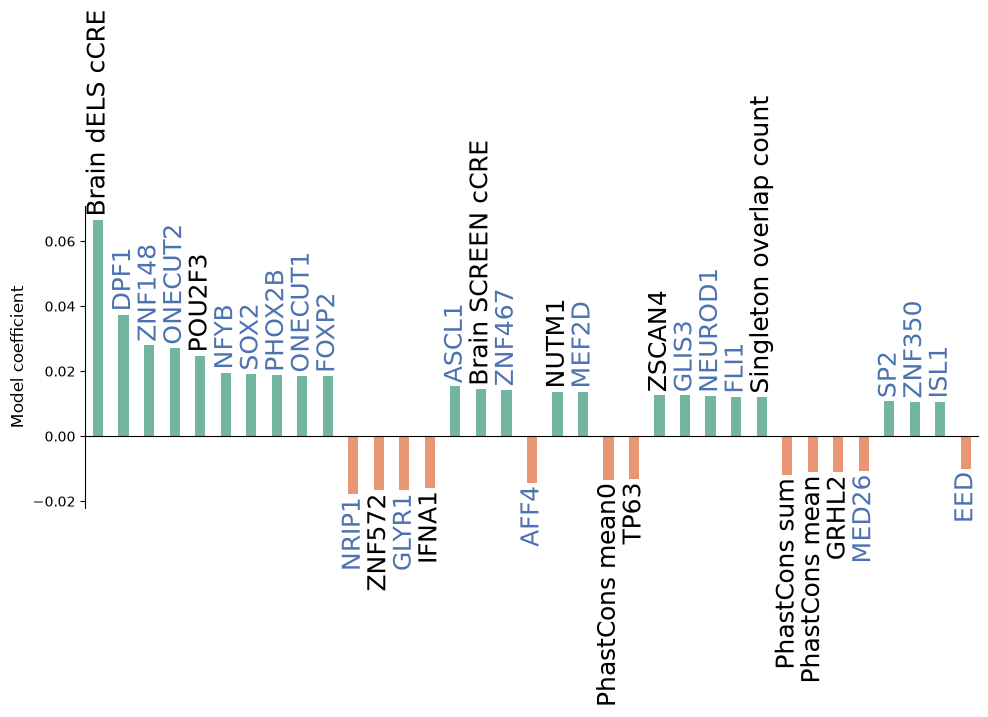

In [15]:
# downloaded from https://www.proteinatlas.org/humanproteome/brain/data#hpa_brain_regions_rna
hpa_brain_path = "./data/rna_brain_region_hpa.tsv.gz"
hpa_brain_df = pd.read_csv(hpa_brain_path, sep="\t")
brain_region_nTPMs = hpa_brain_df.groupby("Gene name")["nTPM"].max().reset_index()

# display names for the non-TFBS features (bare column names double as TF gene symbols
# for the REMAP2022 columns, so only the annotation-flag columns need relabeling)
ploting_name_dict = {
    "is_ngn2_atac_overlap": "NGN2 ATAC overlap",
    "is_H1_SCREEN_cCRE": "H1 SCREEN cCRE",
    "has_overlapping_brain_eQTL": "Brain eQTL overlap",
    "is_brain_e2g_overlap": "Brain e2g overlap",
    "is_brain_SCREEN_cCRE": "Brain SCREEN cCRE",
    "is_heart_SCREEN_cCRE": "Heart SCREEN cCRE",
    "dELS_is_brain_SCREEN_cCRE_group": "Brain dELS cCRE",
    "CA-only_is_brain_SCREEN_cCRE_group": "Brain CA-only cCRE",
    "PLS_is_brain_SCREEN_cCRE_group": "Brain PLS cCRE",
    "pELS_is_brain_SCREEN_cCRE_group": "Brain pELS cCRE",
    "CA-H3K4me3_is_brain_SCREEN_cCRE_group": "Brain CA-H3K4me3 cCRE",
    "CA-TF_is_brain_SCREEN_cCRE_group": "Brain CA-TF cCRE",
    "CA-only_is_heart_SCREEN_cCRE_group": "Heart CA-only cCRE",
    "PLS_is_heart_SCREEN_cCRE_group": "Heart PLS cCRE",
    "dELS_is_heart_SCREEN_cCRE_group": "Heart dELS cCRE",
    "pELS_is_heart_SCREEN_cCRE_group": "Heart pELS cCRE",
    "CA-H3K4me3_is_heart_SCREEN_cCRE_group": "Heart CA-H3K4me3 cCRE",
    "CA-TF_is_heart_SCREEN_cCRE_group": "Heart CA-TF cCRE",
    "phastCons_mean0": "PhastCons mean0",
    "phastCons_mean": "PhastCons mean",
    "phastCons_sum": "PhastCons sum",
    "singleton_overlap_count": "Singleton overlap count",
}


def plot_vertical_coefficients(
    model, feature_names, top_n=100, pos_color="#72B6A1", neg_color="#E99675",
    figsize=(16, 6), fontsize=8, bar_width=0.6,
    expression_df=None, gene_col="gene_name", expression_col="nTPM", expression_threshold=5,
    expressed_color="#4C72B0", not_expressed_color="black", output_path=None,
):
    """Vertical coefficient bars sorted by |coefficient|, optionally coloring TF labels by brain expression."""
    coefs = pd.Series(model.coef_, index=feature_names)
    coefs = coefs[coefs != 0]
    coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index)
    if top_n is not None:
        coefs = coefs.iloc[:top_n]

    use_expression = expression_df is not None and gene_col in expression_df.columns and expression_col in expression_df.columns
    expr_map = expression_df.set_index(gene_col)[expression_col].to_dict() if use_expression else {}

    colors = [pos_color if v > 0 else neg_color for v in coefs.values]

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(coefs))
    y = coefs.values
    ax.bar(x, y, color=colors, width=bar_width)

    for i, (coef, name) in enumerate(zip(y, coefs.index)):
        offset = 0.001 if coef >= 0 else -0.001
        display_name = ploting_name_dict.get(name, name)
        if name in expr_map:
            label_color = expressed_color if expr_map[name] >= expression_threshold else not_expressed_color
        else:
            label_color = not_expressed_color
        ax.text(
            i, coef + offset, display_name, ha="center", va="bottom" if coef >= 0 else "top",
            rotation=90, fontsize=fontsize, color=label_color,
        )

    ax.set_ylabel("Model coefficient", fontsize=12)
    ax.set_xticks([])
    ax.set_xlim(-0.5, len(coefs) - 0.5)
    ax.axhline(0, color="black", linewidth=0.8)
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=True)
    plt.tight_layout()

    if output_path:
        plt.savefig(output_path.rsplit(".", 1)[0] + ".svg", dpi=300, bbox_inches="tight")
        plt.savefig(output_path.rsplit(".", 1)[0] + ".png", dpi=300, bbox_inches="tight")
    plt.show()


plot_vertical_coefficients(
    model_all_regions, feature_cols, top_n=35, figsize=(10, 7), fontsize=18, bar_width=0.4,
    pos_color="#72B6A1", neg_color="#E99675",
    expression_df=brain_region_nTPMs, gene_col="Gene name", expression_col="nTPM",
    output_path=os.path.join(base_figure_dir, "top_elastic_net_coefficients.png") if writing else None,
)

## Supplementary table: nonzero elastic-net coefficients

In [18]:
coef_df = pd.DataFrame({"feature": feature_cols_curr_model, "coefficient": model_all_regions.coef_})
coef_df_nonzero = coef_df[coef_df["coefficient"] != 0].copy()
coef_df_nonzero["abs_coefficient"] = coef_df_nonzero["coefficient"].abs()
coef_df_nonzero.sort_values(by="abs_coefficient", ascending=False, inplace=True)
coef_df_nonzero.drop(columns=["abs_coefficient"], inplace=True)

if writing:
    xlsx_path = "data/supplementary/ngn2_activity_elastic_net_coefficients.xlsx"
    tsv_path = "data/supplementary/ngn2_activity_elastic_net_model_all_regions_removed_na_phastcons_R2_test_0.0308_nonzero_coefficients.tsv.gz"
    coef_df_nonzero.to_excel(xlsx_path, index=False)
    coef_df_nonzero.to_csv(tsv_path, sep="\t", index=False)

## Which TFs matter most, and how do they compare with the enrichment-derived candidate list?
`enriched_tfs_active_sequences` is an independently derived list of TFs enriched in
active sequences (from the separate TFBS-enrichment workflow); here we check how
many of them carry nonzero elastic-net coefficients and where they rank.

In [19]:
coefs = pd.Series(model_all_regions.coef_, index=feature_cols)
all_coefs = coefs.copy()
print(f"Total coefficients: {len(coefs)}")
print(f"Non-zero coefficients: {np.sum(coefs != 0)}")
coefs = coefs[coefs != 0]
coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).index)

for top_n in [15, 30, 35, 100, 208]:
    top_coefs = coefs.iloc[:top_n]
    n_positive = np.sum(top_coefs > 0)
    n_negative = np.sum(top_coefs < 0)
    print(f"Top {top_n} coefficients: {n_positive} positive, {n_negative} negative ({n_positive / n_negative:.2f} times more positive than negative)")

enriched_tfs_active_sequences = [
    "ZNF621", "RFX2", "THAP11", "DDX21", "ARID3B", "KLF15", "KAT2B", "ZNF740", "ZNF354B", "ZNF93",
    "KLF12", "DPF1", "ZFP42", "SAFB2", "POU4F2", "ZNF350", "PHF19", "SP3", "ASXL3", "NFYB", "NFYA",
    "GABPB1", "SHOX2", "ZBTB11", "RFX3", "VEZF1", "NFYC", "GLYR1", "USF1", "ZSCAN4", "SP2", "RFX1", "SP4",
]

enriched_tfs_effects = all_coefs[enriched_tfs_active_sequences]
n_total = len(enriched_tfs_effects)
n_nonzero = np.sum(enriched_tfs_effects != 0)
n_positive = np.sum(enriched_tfs_effects > 0)
n_negative = np.sum(enriched_tfs_effects < 0)
print(f"Enriched TFs: {n_nonzero} non-zero effects out of {n_total} ({n_nonzero/n_total:.2%})")
print(f"Enriched TFs: {n_positive} positive effects out of {n_total} ({n_positive/n_total:.2%})")
print(f"Enriched TFs: {n_negative} negative effects out of {n_total} ({n_negative/n_total:.2%})")

# top 29 |coefficient| TFBS features, and their overlap with the enrichment-derived list
tfbs_coefs = coefs[coefs.index.isin(tfbs_cols)].copy()
tfbs_coefs = tfbs_coefs.reindex(tfbs_coefs.abs().sort_values(ascending=False).index)
general_top_29 = tfbs_coefs.abs().nlargest(29).index.tolist()

enriched_tfs_positions = tfbs_coefs.index.get_indexer(enriched_tfs_active_sequences)
enriched_tfs_positions_dict = dict(zip(enriched_tfs_active_sequences, enriched_tfs_positions))
enriched_tfs_in_top30 = {tf: pos for tf, pos in enriched_tfs_positions_dict.items() if 0 <= pos < 30}
print(f"Enriched TFs in top 30: {len(enriched_tfs_in_top30)}")
print(enriched_tfs_in_top30)

print("Overlap between top 29 |coefficient| TFBS and the enrichment-derived list:")
print(set(general_top_29).intersection(set(enriched_tfs_active_sequences)))

# top 20 positive / negative TFBS coefficients, for the "increasing vs decreasing" TF lists
positive_coefs = coefs[(coefs > 0) & (coefs.index.isin(tfbs_cols))]
negative_coefs = coefs[(coefs < 0) & (coefs.index.isin(tfbs_cols))]
positive_coefs_top20 = positive_coefs.nlargest(20).index.tolist()
negative_coefs_top20 = negative_coefs.nsmallest(20).index.tolist()
print("Top 20 positive-coefficient TFBS:", positive_coefs_top20)
print("Top 20 negative-coefficient TFBS:", negative_coefs_top20)

Total coefficients: 1184
Non-zero coefficients: 167
Top 15 coefficients: 11 positive, 4 negative (2.75 times more positive than negative)
Top 30 coefficients: 20 positive, 10 negative (2.00 times more positive than negative)
Top 35 coefficients: 23 positive, 12 negative (1.92 times more positive than negative)
Top 100 coefficients: 54 positive, 46 negative (1.17 times more positive than negative)
Top 208 coefficients: 86 positive, 81 negative (1.06 times more positive than negative)
Enriched TFs: 14 non-zero effects out of 33 (42.42%)
Enriched TFs: 12 positive effects out of 33 (36.36%)
Enriched TFs: 2 negative effects out of 33 (6.06%)
Enriched TFs in top 30: 6
{'DPF1': np.int64(0), 'ZNF350': np.int64(26), 'NFYB': np.int64(4), 'GLYR1': np.int64(11), 'ZSCAN4': np.int64(19), 'SP2': np.int64(25)}
Overlap between top 29 |coefficient| TFBS and the enrichment-derived list:
{'NFYB', 'SP2', 'ZNF350', 'GLYR1', 'ZSCAN4', 'DPF1'}
Top 20 positive-coefficient TFBS: ['DPF1', 'ZNF148', 'ONECUT2', 'P

## Cross-check: TFBS presence-vs-activity-bin trend (Spearman) vs. elastic-net coefficient
For each enriched TF, bin elements by activity quintile and test whether the fraction
of elements carrying that TFBS trends up/down with activity; compare the trend to the
TF's model coefficient.

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


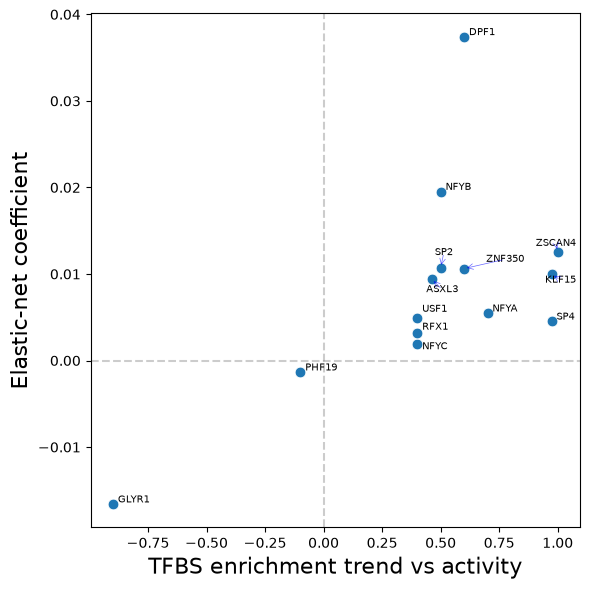

In [20]:
required_cols = ["normalized_activity_NGN2"] + enriched_tfs_active_sequences
df_sub = combined_annotation_activity_tfbs_count_elements_df[required_cols].copy()
df_long = df_sub.reset_index(names="sequence_id").melt(
    id_vars=["sequence_id", "normalized_activity_NGN2"], var_name="TF", value_name="tfbs_count",
)
df_long = df_long[df_long["normalized_activity_NGN2"].notna()]
df_long["activity_bin"] = pd.qcut(df_long["normalized_activity_NGN2"], q=5, labels=False)

tf_bin_summary = (
    df_long.groupby(["TF", "activity_bin"])
    .agg(frac_present=("tfbs_count", lambda x: (x > 0).mean()), mean_tfbs=("tfbs_count", "mean"), n_seq=("tfbs_count", "size"))
    .reset_index()
)

tf_direction_results = []
for tf, sub in tf_bin_summary.groupby("TF"):
    corr, pval = spearmanr(sub["activity_bin"], sub["frac_present"])
    direction = "Increasing" if (pval < 0.05 and corr > 0) else "Decreasing" if (pval < 0.05 and corr < 0) else "Neutral"
    tf_direction_results.append({"TF": tf, "spearman_r": corr, "pval": pval, "direction": direction})
tf_direction_df = pd.DataFrame(tf_direction_results).sort_values("spearman_r", ascending=False)

coef_lookup_df = pd.DataFrame({"TF": coefs.index, "coefficient": coefs.values})
tf_direction_df = tf_direction_df.merge(coef_lookup_df[["TF", "coefficient"]], on="TF", how="left")

from adjustText import adjust_text

# Filter to only TFs with coefficients
tf_direction_df_valid = tf_direction_df[tf_direction_df["coefficient"].notna()].copy()

# Increase figure size to give more space
plt.figure(figsize=(6, 6))
ax = sns.scatterplot(data=tf_direction_df_valid, x="spearman_r", y="coefficient", s=60)

plt.axhline(0, color="grey", linestyle="--", alpha=0.4)
plt.axvline(0, color="grey", linestyle="--", alpha=0.4)
plt.xlabel("TFBS enrichment trend vs activity", fontsize=16)
plt.ylabel("Elastic-net coefficient", fontsize=16)

# Create text annotations
texts = []
for i, row in tf_direction_df_valid.iterrows():
    texts.append(plt.text(row["spearman_r"], row["coefficient"],
                         f' {row["TF"]} ', fontsize=7))

# Tune adjust_text for maximum spacing
adjust_text(texts,
            arrowprops=dict(arrowstyle='->', color='blue', lw=0.5, alpha=0.6),
            expand_points=(2.0, 2.0),      # More space around points
            expand_text=(1.2, 1.2),         # More space around text
            force_points=(1.0, 1.0),        # Stronger repulsion between points
            force_text=(1.0, 1.0),          # Stronger repulsion between text labels
            lim=500,                        # Allow longer arrows
            arrowpad=0.5)                   # Space between text and arrow start

plt.tight_layout()
plt.show()

## Cross-check: TF enrichment in high- vs. low-activity quantiles (Fisher exact) vs. coefficient

In [21]:
low = combined_annotation_activity_tfbs_count_elements_df["normalized_activity_NGN2"] <= combined_annotation_activity_tfbs_count_elements_df["normalized_activity_NGN2"].quantile(0.2)
high = combined_annotation_activity_tfbs_count_elements_df["normalized_activity_NGN2"] >= combined_annotation_activity_tfbs_count_elements_df["normalized_activity_NGN2"].quantile(0.8)

tf_high_low_results = []
for tf in enriched_tfs_active_sequences:
    table = [
        [(combined_annotation_activity_tfbs_count_elements_df.loc[low, tf] > 0).sum(),
         (combined_annotation_activity_tfbs_count_elements_df.loc[low, tf] == 0).sum()],
        [(combined_annotation_activity_tfbs_count_elements_df.loc[high, tf] > 0).sum(),
         (combined_annotation_activity_tfbs_count_elements_df.loc[high, tf] == 0).sum()],
    ]
    if any(cell == 0 for row in table for cell in row):
        print(f"Skipping TF {tf} due to zero in contingency table: {table}")
        continue
    oddsratio, pval = fisher_exact(table)
    tf_high_low_results.append({"TF": tf, "log2_OR": np.log2(oddsratio), "pval": pval})

tf_high_low_enrichment_df = pd.DataFrame(tf_high_low_results).sort_values("log2_OR", ascending=False)
tf_high_low_enrichment_df = tf_high_low_enrichment_df.merge(coef_lookup_df[["TF", "coefficient"]], on="TF", how="left")
tf_high_low_enrichment_df

Skipping TF ZNF621 due to zero in contingency table: [[np.int64(0), np.int64(4894)], [np.int64(2), np.int64(4892)]]
Skipping TF RFX2 due to zero in contingency table: [[np.int64(0), np.int64(4894)], [np.int64(3), np.int64(4891)]]


,TF,log2_OR,pval,coefficient
0,GLYR1,1.040475,7.942628e-03,-0.016594
1,ARID3B,1.000590,6.874042e-01,NaN
2,ZNF93,0.415332,1.000000e+00,NaN
3,ZNF354B,0.322223,1.000000e+00,NaN
4,PHF19,0.264517,5.889993e-01,-0.001344
5,KLF12,0.000000,1.000000e+00,NaN
6,SAFB2,0.000000,1.000000e+00,NaN
7,ZNF740,0.000000,1.000000e+00,NaN
8,ZFP42,-0.125826,1.000000e+00,NaN
9,RFX1,-0.347763,9.616379e-02,0.003238


## Robustness checks: does class imbalance explain the model's low R^2?
~1900 significant vs. ~20000 non-significant elements. The checks below downsample
non-significant elements to several sig:non-sig ratios and refit, to see whether
balancing the classes recovers a stronger fit. Conclusion (see distribution
diagnostics further below): the regression target is not well predicted by this
feature set with a simple linear model regardless of class balance, so the
manuscript reports the all-region model above rather than a rebalanced one.

In [ ]:
def downsample_and_train(df_scaled, binary_cols, continuous_cols, tfbs_cols, target_col, ratio=1.0, random_state=42, chrom_col="chr"):
    """Downsample non-significant sequences per-chromosome to `ratio` x the number of significant ones, then refit."""
    np.random.seed(random_state)
    feature_cols = binary_cols + continuous_cols + tfbs_cols
    df = df_scaled.copy()
    sig = df[df["significant_region_NGN2"] == True]
    nonsig = df[df["significant_region_NGN2"] == False]

    nonsig_down = nonsig.groupby(chrom_col, group_keys=False).apply(
        lambda x: x.sample(n=min(int(len(sig[sig[chrom_col] == x.name]) * ratio), len(x)), replace=False)
    )
    df_balanced = pd.concat([sig, nonsig_down])
    df_balanced_scaled, _ = scale_columns(df_balanced, continuous_cols, tfbs_cols)

    train_idx = df_balanced_scaled[chrom_col].isin(train_chroms)
    test_idx = df_balanced_scaled[chrom_col].isin(test_chroms)
    X_train = df_balanced_scaled.loc[train_idx, feature_cols]
    y_train = df_balanced_scaled.loc[train_idx, target_col]
    X_test = df_balanced_scaled.loc[test_idx, feature_cols]
    y_test = df_balanced_scaled.loc[test_idx, target_col]

    model = train_elastic_net(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    tau, _ = kendalltau(y_test, y_pred_test)
    return {
        "r2_train": r2_score(y_train, y_pred_train), "r2_test": r2_score(y_test, y_pred_test),
        "tau": tau, "tau2": tau * tau, "n_sig": len(sig), "n_nonsig": len(nonsig_down), "dataset": df_balanced_scaled,
    }, model


feature_cols = all_binary_cols + continuous_cols + tfbs_cols
df = combined_annotation_activity_tfbs_count_elements_df[["name", "chr", "normalized_activity_NGN2", "significant_region_NGN2"] + feature_cols].copy()
df[all_binary_cols] = df[all_binary_cols].astype(int)
df[tfbs_cols] = df[tfbs_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)
tfbs_cols = filter_tfbs_columns(df, tfbs_cols, min_nonzero=10)
print(f"TFBS columns kept: {len(tfbs_cols)}")

feature_cols = all_binary_cols + continuous_cols + tfbs_cols

result, model = downsample_and_train(
    df, binary_cols=all_binary_cols, continuous_cols=continuous_cols, tfbs_cols=tfbs_cols,
    target_col="normalized_activity_NGN2", ratio=1.0, chrom_col="chr", random_state=23,
)
print(result)

TFBS columns kept: 990


## Full-data vs. balanced-data (ratio 1) model performance
Makes the class-imbalance comparison above visually explicit: the all-region model's
test R^2 vs. the ratio-1 (balanced) downsampled model's test R^2.

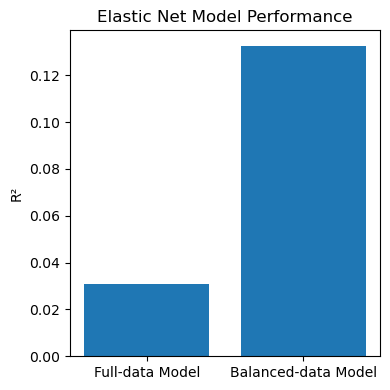

Model and coefficients for ratio 0.5 already exist. Skipping...
Model and coefficients for ratio 1 already exist. Skipping...
Model and coefficients for ratio 3 already exist. Skipping...


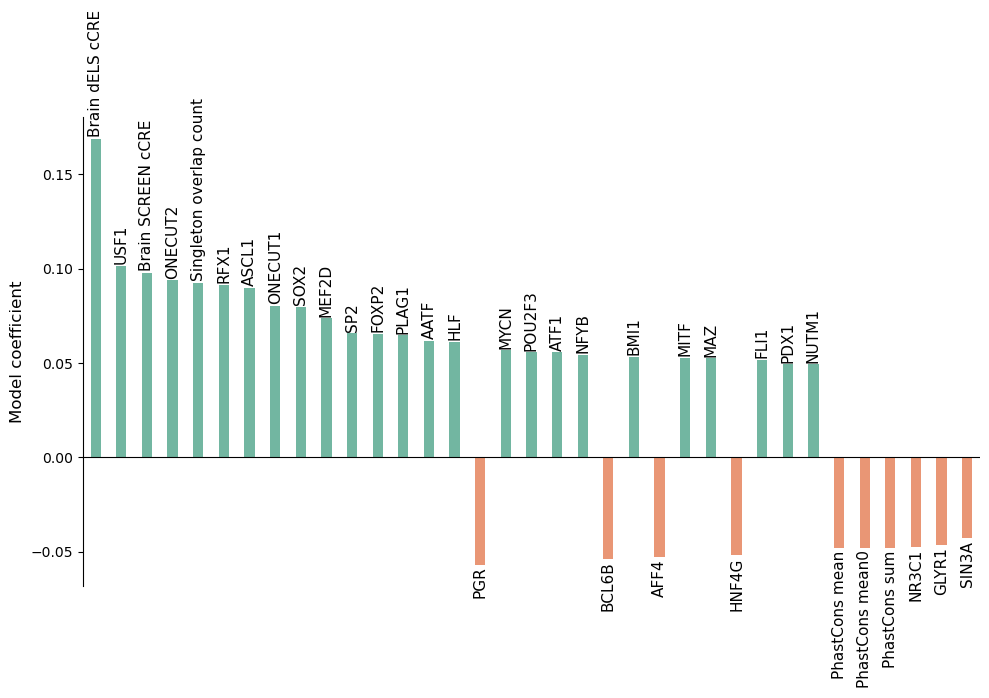

In [ ]:
all_model_r2 = current_metrics_test["r2"]
balanced_dataset_model_r2 = result["r2_test"]

plt.figure(figsize=(4, 4))
plt.bar(["Full-data Model", "Balanced-data Model"], [all_model_r2, balanced_dataset_model_r2])
plt.ylabel("R²")
plt.title("Elastic Net Model Performance")
plt.tight_layout()
plt.show()


output_dir = "results/elastic_net/differnet_ratios/"
os.makedirs(output_dir, exist_ok=True)
for ratio in [0.5, 1, 3]:
    model_output_path = os.path.join(output_dir, f"ngn2_activity_elastic_net_model_downsampled_ratio_filtered_{ratio}.pkl")
    coefficients_output_path = os.path.join(output_dir, f"ngn2_activity_elastic_net_model_downsampled_ratio_filtered_{ratio}_coefficient.tsv")
    if os.path.exists(model_output_path) and os.path.exists(coefficients_output_path):
        print(f"Model and coefficients for ratio {ratio} already exist. Skipping...")
        continue
    print(f"=== Downsampling ratio: {ratio} ===")
    result, model = downsample_and_train(
        df, binary_cols=all_binary_cols, continuous_cols=continuous_cols, tfbs_cols=tfbs_cols,
        target_col="normalized_activity_NGN2", ratio=ratio, chrom_col="chr", random_state=23,
    )
    print(result)
    if writing:
        joblib.dump(model, model_output_path)
        coef_df = pd.DataFrame({"feature": feature_cols, "coefficient": model.coef_})
        coef_df.to_csv(coefficients_output_path, sep="\t", index=False)


plot_vertical_coefficients(
    model, feature_cols, top_n=35, pos_color="#72B6A1", neg_color="#E99675", figsize=(10, 7), fontsize=11, bar_width=0.4,
)